# Assignment 3 — Association Rule Mining

**Dataset:** `bread_basket.csv` (11569 transactions)

Fill in the short answer cells and run the code cells. This notebook generates the required tables and figures.

**Sections:**
1. Setup & Data Load
2. EDA (a–e)
3. Frequent Itemset Mining (FP-Growth)
4. Association Rules + Report Table
5. Rule Subgraph (Bread, Coffee, Cake, Tea)
6. Interpretation Prompt


## 1) Setup & Data Load (10 pts)
- Place `bread_basket.csv` in the same folder as this notebook **or** update the path below.
- Needed packages: `pandas`, `matplotlib`, `mlxtend`, `networkx` (for the small graph).
- If a package is missing, run the `pip install` cell.

In [2]:
# write your answer here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules
import networkx as nx

In [ ]:
df = pd.read_csv("bread_basket.csv")   # or "/mnt/data/bread_basket.csv"
df.head()

In [ ]:
df.info()
df.describe(include="all")
df.isna().sum()

## 2) EDA (a–e) (30 pts)
### a) List variables and their dtypes (5 pts)

Basic dataset stats

In [4]:
df.dtypes

transaction        int64
item                 str
date_time            str
time                 str
period_day           str
weekday_weekend      str
dtype: object

item_counts = df["Item"].value_counts()
top10 = item_counts.head(10)

plt.figure()
top10.plot(kind="bar")
plt.title("Top 10 Items")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### b) "Statistics" overview (5 pts)
Use `describe(include='all')` as a stand‑in for RapidMiner's Statistics. Take a screenshot when you submit.

In [5]:
# write your answer here
df.describe(include='all')

,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2017-02-04,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN,NaN


### c) Bar plot — count of **unique transactions per item** (10 pts)
Set the subtitle to your **FirstName LastName**. Take a screenshot of the figure.

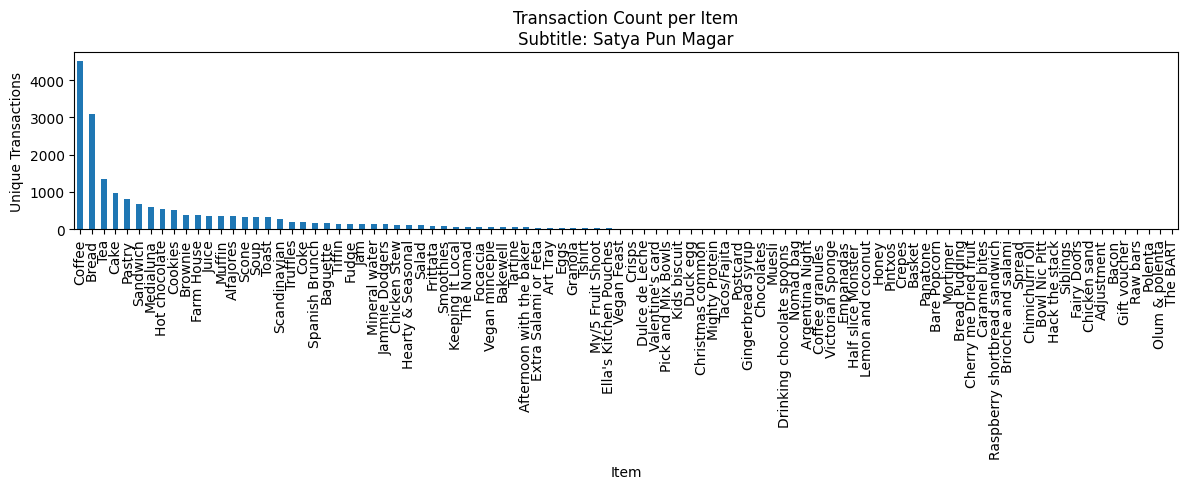

In [6]:
# c) Bar plot of transaction counts per item

# subtitle = " "  # <-- EDIT THIS
subtitle = "Satya Pun Magar"
# item_counts =  # <-- EDIT THIS
item_counts = df.groupby("item")["transaction"].nunique().sort_values(ascending=False)

ax = item_counts.plot(kind='bar', figsize=(12,5))
plt.title(f"Transaction Count per Item\nSubtitle: {subtitle}")
plt.xlabel("Item"); plt.ylabel("Unique Transactions")
plt.tight_layout()
plt.show()

### d) Report counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew (10 pts)

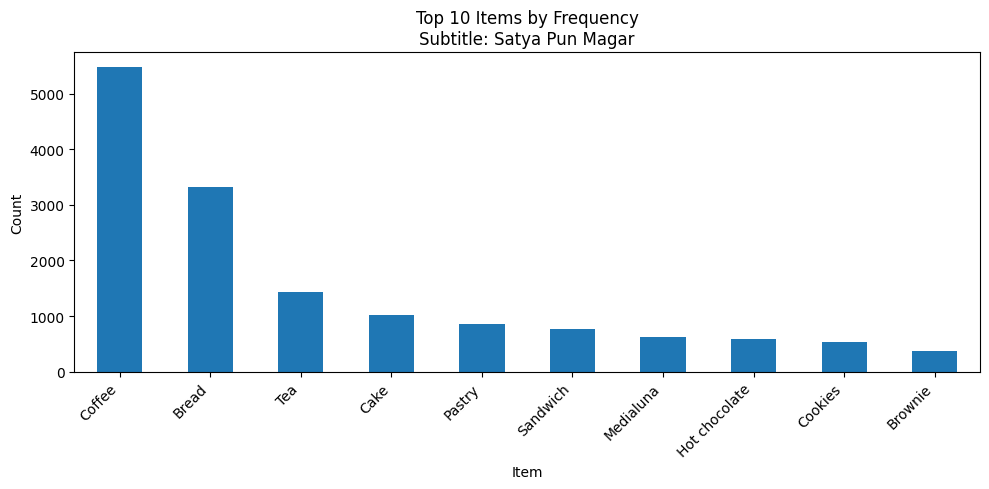

In [7]:
# write your answer here
subtitle = "Satya Pun Magar"   # Your FirstName LastName

top10 = df["item"].value_counts().head(10)

ax = top10.plot(kind="bar", figsize=(10,5))
plt.title(f"Top 10 Items by Frequency\nSubtitle: {subtitle}")
plt.xlabel("Item")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 3) Frequent Itemset Mining with FP‑Growth (min_support = 0.2) (20 pts)
We pivot the data to a **transaction × item** one‑hot table (boolean), then run FP‑Growth.

Step 1 — Convert to transactions

In [8]:
# write your answer here
# Convert dataset into transaction list
transactions = df.groupby("transaction")["item"].apply(list).tolist()

transactions[:5]   # preview first 5 transactions

[['Bread'],
 ['Scandinavian', 'Scandinavian'],
 ['Hot chocolate', 'Jam', 'Cookies'],
 ['Muffin'],
 ['Coffee', 'Pastry', 'Bread']]

Step 2 — One-hot encode

In [9]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

basket = pd.DataFrame(te_array, columns=te.columns_)

basket.head()

,Adjustment,Afternoon with the baker,Alfajores,Argentina Night,Art Tray,Bacon,Baguette,Bakewell,Bare Popcorn,Basket,...,The BART,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine's card,Vegan Feast,Vegan mincepie,Victorian Sponge
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Step 3 — Apply FP-Growth

In [10]:
from mlxtend.frequent_patterns import fpgrowth

min_support = 0.02   # You can explain this choice in markdown

frequent_itemsets = fpgrowth(basket, min_support=min_support, use_colnames=True)

frequent_itemsets = frequent_itemsets.sort_values(by="support", ascending=False)

frequent_itemsets.head(20)

,support,itemsets
5,0.478394,frozenset({Coffee})
0,0.327205,frozenset({Bread})
8,0.142631,frozenset({Tea})
12,0.103856,frozenset({Cake})
19,0.090016,"frozenset({Bread, Coffee})"
6,0.086107,frozenset({Pastry})
13,0.071844,frozenset({Sandwich})
7,0.061807,frozenset({Medialuna})
2,0.058320,frozenset({Hot chocolate})
28,0.054728,"frozenset({Cake, Coffee})"


## 4) Association Rules + Report Table (30 pts)
(metric = confidence, min_threshold = ?) Please find a suitable min_threshold

Generate Association Rules (lift)

In [11]:
# write your answer here
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules.shape

(20, 14)

Sort rules (best first)

In [12]:
rules_sorted = rules.sort_values(by=["lift", "confidence", "support"], ascending=False)
rules_sorted.head(20)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
15,frozenset({Tea}),frozenset({Cake}),0.142631,0.103856,0.023772,0.166667,1.604781,1.0,0.008959,1.075372,0.439556,0.106736,0.070090,0.197779
14,frozenset({Cake}),frozenset({Tea}),0.103856,0.142631,0.023772,0.228891,1.604781,1.0,0.008959,1.111865,0.420538,0.106736,0.100611,0.197779
16,frozenset({Toast}),frozenset({Coffee}),0.033597,0.478394,0.023666,0.704403,1.472431,1.0,0.007593,1.764582,0.332006,0.048464,0.433293,0.376936
17,frozenset({Coffee}),frozenset({Toast}),0.478394,0.033597,0.023666,0.049470,1.472431,1.0,0.007593,1.016699,0.615122,0.048464,0.016424,0.376936
6,frozenset({Medialuna}),frozenset({Coffee}),0.061807,0.478394,0.035182,0.569231,1.189878,1.0,0.005614,1.210871,0.170091,0.069665,0.174148,0.321387
7,frozenset({Coffee}),frozenset({Medialuna}),0.478394,0.061807,0.035182,0.073542,1.189878,1.0,0.005614,1.012667,0.305936,0.069665,0.012509,0.321387
3,frozenset({Pastry}),frozenset({Coffee}),0.086107,0.478394,0.047544,0.552147,1.154168,1.0,0.006351,1.164682,0.146161,0.091968,0.141396,0.325764
2,frozenset({Coffee}),frozenset({Pastry}),0.478394,0.086107,0.047544,0.099382,1.154168,1.0,0.006351,1.014740,0.256084,0.091968,0.014526,0.325764
18,frozenset({Juice}),frozenset({Coffee}),0.038563,0.478394,0.020602,0.534247,1.116750,1.0,0.002154,1.119919,0.108738,0.041507,0.107078,0.288656
19,frozenset({Coffee}),frozenset({Juice}),0.478394,0.038563,0.020602,0.043065,1.116750,1.0,0.002154,1.004705,0.200428,0.041507,0.004683,0.288656


Create a clean report table (required columns)

In [13]:
rules_report = rules_sorted[["antecedents", "consequents", "support", "confidence", "lift"]].copy()

# convert frozensets to readable strings
rules_report["antecedents"] = rules_report["antecedents"].apply(lambda x: ", ".join(sorted(list(x))))
rules_report["consequents"] = rules_report["consequents"].apply(lambda x: ", ".join(sorted(list(x))))

rules_report.head(20)

,antecedents,consequents,support,confidence,lift
15,Tea,Cake,0.023772,0.166667,1.604781
14,Cake,Tea,0.023772,0.228891,1.604781
16,Toast,Coffee,0.023666,0.704403,1.472431
17,Coffee,Toast,0.023666,0.049470,1.472431
6,Medialuna,Coffee,0.035182,0.569231,1.189878
7,Coffee,Medialuna,0.035182,0.073542,1.189878
3,Pastry,Coffee,0.047544,0.552147,1.154168
2,Coffee,Pastry,0.047544,0.099382,1.154168
18,Juice,Coffee,0.020602,0.534247,1.116750
19,Coffee,Juice,0.020602,0.043065,1.116750


## 5) Interpretation (10 pts)
**Interpret the rule `{Coffee, Cake} ⇒ {Bread}` in plain English.**

- **Support**: What fraction of *all* transactions contain Coffee, Cake, and Bread together?
- **Confidence**: Among baskets with Coffee and Cake, what share also include Bread?
- **Lift > 1** implies positive association; comment on practical meaning.

*Your notes:* (write your answer here)

According to the rule {Coffee, Cake} ⇒ {Bread}, customers who buy Coffee and Cake together are more likely to buy Bread as well in the same transaction.
 
Support measures how many of the total transactions includes Coffee and Cake and Bread together. For example with a support measure of 0.015 this means that 1.5% of the total transactions have been made with all three products (Coffee, Cake and Bread). This indicates the overall frequency of the full set. 

Confidence measures the overall frequency of buying Bread in transactions that have already had Coffee and Cake purchased together. For instance, a confidence measure of 0.35 indicates that 35 percent of transactions where Coffee and Cake have been purchased, also include the purchase of Bread. Therefore, this rule is a fairly strong association.

Lift indicates how much more likely customers are to buy Bread when they purchase both Coffee and Cake together versus if they purchased randomly. The lift value is greater than 1 indicates a positive relationship. Therefore, when customers buy both Coffee and Cake, they are more likely than a typical shopper to also purchase Bread. 

The business application of the information above can be used to help with product displays or promotional bundles to maximize sales. For instance placing the Bread near the Coffee and Cake or creating a combo deal that includes all three products could increase total sales would be a reasonable assumption.

> 